# Making a Neural Network to Predict IDP interaction

Note: The first half of this notebook contains some copies of what was in the data exploration notebook. That's because I wanted to use what I already have.

In [ ]:
# Ignore this, was working in google colab
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Downloaded extensions

In [ ]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.8 MB/s eta 0:00:00


In [ ]:
!pip install transformers

In [ ]:
!pip install torch-Geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.8 MB/s eta 0:00:00


In [ ]:
!pip install skorch

# Imported libraries

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from io import StringIO
import Bio
import sklearn
from Bio.PDB import *
from transformers import AutoTokenizer
from transformers import EsmModel, EsmConfig
import torch
import datasets
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SCOP import *
import warnings
from torch_geometric.data import Data
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import random
import requests
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score

In [ ]:
# Reading the csv file
df = pd.read_csv("/content/drive/MyDrive/Coop/content/DIBS_complete.csv") # Change file path to where everything is stored
# Unneeded columns
df = df.drop(columns=["/database", "Unnamed: 1", "Unnamed: 2"])
# Fixes the gap in the dataframe in the first row caused by /database
new_header = df.iloc[0]
df = df[1:]
df.columns = new_header
pdb_col = "/entry/general/pdb_id"
chain_col = "/entry/evidence/chain_evidence/chain_id"

/tmp/ipykernel_4201/4106057391.py:2: DtypeWarning: Columns (3,15,16,17,18,26,27,29,30,31,32,33,35,37,38,41,42,43,44,46,47,50,51,58,59,61,62,63,64,66,67,70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Coop/content/DIBS_complete.csv")


In [ ]:
pdb_pattern = re.compile(r"^[0-9][a-z0-9]{3}$", re.IGNORECASE)

def reconstruct_from_number(val):
    if pd.isna(val):
        return None

    # If it's already a string, strip whitespace and return if it already matches pattern
    if isinstance(val, str):
        s = val.strip()

        sci_match = re.match(r"^\s*([0-9]+)(?:\.[0-9]+)?[eE]\+?(-?\d+)\s*$", s)
        if sci_match:
            mant = sci_match.group(1)
            exp = int(sci_match.group(2))

            if len(mant) == 1 and 0 <= exp <= 99:
                candidate = f"{mant}e{exp:02d}"

                if pdb_pattern.match(candidate):
                    return candidate.lower()

            if len(mant) == 1 and 0 <= exp:
                candidate = f"{mant}e{exp}"

                if pdb_pattern.match(candidate):
                    return candidate.lower()
        # If it already matches pdb pattern, return normalized
        if pdb_pattern.match(s):
            return s.lower()

        try:
            n = int(s.replace(",", ""))
        except Exception:
            return None
    else:
        # Converts to integer if it"s an integer float
        if isinstance(val, float) and val.is_integer():
            n = int(val)
        elif isinstance(val, (int, np.integer)):
            n = int(val)
        else:
            try:
                n = int(val)
            except Exception:
                return None

    # Format using Python's scientific formatting to get mantissa/exponent
    try:
        s_sci = "{:0.0e}".format(n)  # e.g. "4e+05" or "1e+06"
    except Exception:
        return None

    # Removes plus sign and makes it lower-case
    s_sci = s_sci.replace("+", "").lower()
    m = re.match(r"^([0-9])e(-?\d+)$", s_sci)
    if m:
        mant = m.group(1)
        exp = int(m.group(2))
        if 0 <= exp <= 99:
            candidate = f"{mant}e{exp:02d}"
            if pdb_pattern.match(candidate):
                return candidate.lower()

            candidate2 = f"{mant}e{exp}"

            if pdb_pattern.match(candidate2):
                return candidate2.lower()

    if len(s_sci) == 4 and pdb_pattern.match(s_sci):
        return s_sci.lower()

    return None

In [ ]:
df["pdb_fixed"] = df[pdb_col].apply(reconstruct_from_number)

def final_pdb_value(orig, fixed):
    if fixed is not None:
        return fixed
    if pd.isna(orig):
        return orig
    # Normalize original strings to lowercase and strip
    return str(orig).strip().lower()

df[pdb_col] = [final_pdb_value(o, f) for o, f in zip(df[pdb_col], df["pdb_fixed"])]

In [ ]:
pdb_ids = df["/entry/general/pdb_id"]
pdb_ids.head()
unique_pdb_ids = pdb_ids.unique()
unique_pdb_ids = unique_pdb_ids[1:]

In [ ]:
# Changing the old pdb_id column to the validated one
df_valid = df.dropna(subset=[chain_col]).copy()
df_valid[pdb_col]   = df_valid[pdb_col].astype(str).str.strip().str.lower()
df_valid[chain_col] = df_valid[chain_col].astype(str).str.strip()

df_valid = df_valid.drop_duplicates(subset=[pdb_col, chain_col], keep="first")

df_valid["_row_order"] = np.arange(len(df_valid))
df_valid = df_valid.sort_values("_row_order")

chain_vals = (
    df_valid
      .groupby(pdb_col, sort=False)[chain_col]
      .apply(list)
      .to_dict()
)
for pid in df[pdb_col].astype(str).str.strip().str.lower().unique():
    chain_vals.setdefault(pid, [])

df_valid.drop(columns=["_row_order"], inplace=True, errors="ignore")

In [ ]:
pdbl = PDBList()
parser = PDBParser(PERMISSIVE = True, QUIET = True)

# The Protein Class

In [ ]:
class Protein:
  def __init__(self, pdb_id):
    # Defines the structure and interactions, named by the id
    self.pdb_id = pdb_id
    self.structure = self.get_structure()
    self.chains = []
    self.interactions = []
    self.sequences = {}

# Returns the pdb_id
  def get_pdb_id(self):
    return self.pdb_id

# Gets the structure of the protein from the ".ent" file
  def get_structure(self):
    pdbl = PDBList()
    parser = PDBParser(PERMISSIVE = True, QUIET = True)
    structure = parser.get_structure(self.pdb_id, "/content/drive/MyDrive/Coop/content/pdb_ids/pdb"+self.pdb_id+".ent") # Change file path to where everything is stored
    return structure

# Uses the chains from the database to combine to store them all in a list
  def set_chains(self, list_of_chains):
    for i in list_of_chains:
      if i == self.pdb_id:
        self.chains.append(list_of_chains[i])
        break

  def get_chains(self):
    return self.chains

# Gets the list of residues with the option to remove the idp
  def get_residues(self, idp=True):
    if idp == True:
      return list(self.structure.get_residues())
    else:
      total_residues = []
      model = next(self.structure.get_models())

      chains_in_struct = [
              ch for chain_id in self.get_chains()[0]
              for ch in model if ch.id == chain_id
            ]
      for i in chains_in_struct[1:]:
        for j in i.get_residues():
          total_residues.append(j)
      return total_residues

# Get the chains from the bio python module, check if they interact, if they do, list where
  def set_interactions(self, cutoff=5.0):
        model = next(self.structure.get_models())  # get first model

        # Getting the chains in the structure
        chains_in_struct = [
              ch for chain_id in self.get_chains()[0]
              for ch in model if ch.id == chain_id
            ]

        if len(chains_in_struct) < 2:
            print("Not enough chains to compare.")
            return
        # Seperating between the idp and the other chain
        idp_chain = chains_in_struct[0]

        for other_chain in chains_in_struct[1:]:
            for res_a in idp_chain.get_residues():
                if res_a.id[0] != " ":
                    continue
                for res_b in other_chain.get_residues():
                    if res_b.id[0] != " ":
                        continue

                    interacting = False
                    for atom_a in res_a:
                        for atom_b in res_b:
                            distance = atom_a - atom_b  # Biopython atom distance
                            if distance <= cutoff:
                                self.interactions.append((res_a.get_resname(), idp_chain.id, res_a.id[1], res_b.get_resname(), other_chain.id, res_b.id[1]))
                                interacting = True
                                break
                        if interacting:
                            break

  # Gets the interactions, Ex: (IDP residue, IDP chain ID, idp residue ID, Residue, other chain ID, other chain ID)
  def get_interactions(self):
    return self.interactions

  # Sets all the sequences of a protein into a dictionary and seperates them by chain
  def set_sequences(self):
    parser = PDBParser(QUIET=True)
    ppb = PPBuilder()
    model = next(self.structure.get_models())
    for chain in model:
            chain_id = chain.get_id()

            polypeptides = ppb.build_peptides(chain)

            if polypeptides:
                # Concatenate all polypeptide sequences in the chain
                chain_sequence = "".join([str(pp.get_sequence()) for pp in polypeptides])
                self.sequences[chain_id] = chain_sequence

  # Gets the sequences of a protein, seperated by chain
  def get_sequences(self):
    return self.sequences



In [ ]:
protein_list = []
for i in unique_pdb_ids:
  protein_list.append(Protein(i))

The following functions were made seperately while preparing the list of proteins due to the excessive RAM usage.

In [ ]:
for i in protein_list:
  i.set_chains(chain_vals)

In [ ]:
for i in protein_list:
  i.set_interactions()

In [ ]:
for i in protein_list:
  i.set_sequences()

Using ESM to get tensors

In [ ]:
print(protein_list[0].get_interactions())
print(len(protein_list[0].get_interactions()))

[('HIS', 'A', 380, 'ILE', 'B', 1122), ('HIS', 'A', 380, 'PRO', 'B', 1123), ('LYS', 'A', 381, 'ILE', 'B', 1122), ('LYS', 'A', 381, 'PRO', 'B', 1123), ('LYS', 'A', 381, 'TYR', 'B', 1167), ('LYS', 'A', 381, 'ARG', 'B', 1169), ('LEU', 'A', 383, 'GLN', 'B', 1113), ('LEU', 'A', 383, 'PRO', 'B', 1114), ('LEU', 'A', 383, 'VAL', 'B', 1115), ('LEU', 'A', 383, 'LEU', 'B', 1120), ('LEU', 'A', 383, 'ILE', 'B', 1122), ('LEU', 'A', 383, 'ARG', 'B', 1173), ('LEU', 'A', 383, 'VAL', 'B', 1174), ('LEU', 'A', 383, 'PHE', 'B', 1177), ('MET', 'A', 384, 'TYR', 'B', 1167), ('MET', 'A', 384, 'ASN', 'B', 1168), ('MET', 'A', 384, 'ARG', 'B', 1169), ('MET', 'A', 384, 'SER', 'B', 1172), ('MET', 'A', 384, 'ARG', 'B', 1173), ('MET', 'A', 384, 'VAL', 'B', 1174), ('MET', 'A', 384, 'TYR', 'B', 1175), ('PHE', 'A', 385, 'ARG', 'B', 1173), ('PHE', 'A', 385, 'VAL', 'B', 1174), ('LYS', 'A', 386, 'LEU', 'B', 1120), ('LYS', 'A', 386, 'ARG', 'B', 1173)]
25


# Embedding the proteins

Using meta's ESM2 model, I embedded the proteins into being vectors that have 320 dimensions per residue, as I wanted to track the residues to determine whether or not the proteins could be bound to an idp.

In [ ]:
model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)
esm_model = EsmModel.from_pretrained(model_name)
esm_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 320, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-5): 6 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=320, out_features=320, bias=True)
            (key): Linear(in_features=320, out_features=320, bias=True)
            (value): Linear(in_features=320, out_features=320, bias=True)
            (rotary_embeddings): RotaryEmbedding()
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=320, out_features=320, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
          (dense): Linear(in_features=320, out_features=1280, bias=True)
        )
        (output): EsmOutput(
        

In [ ]:
# Convert a Protein object to ESM embeddings
def get_protein_embeddings(protein):
    sequences = protein.get_sequences()
    embeddings = {}

    for chain_id, sequence in sequences.items():
        inputs = tokenizer(sequence, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = esm_model(**inputs)
            hidden_states = outputs.last_hidden_state

        embeddings[chain_id] = hidden_states[:, 1:-1, :]

    return embeddings

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
esm_model.to(device)

EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 320, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-5): 6 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=320, out_features=320, bias=True)
            (key): Linear(in_features=320, out_features=320, bias=True)
            (value): Linear(in_features=320, out_features=320, bias=True)
            (rotary_embeddings): RotaryEmbedding()
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=320, out_features=320, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
          (dense): Linear(in_features=320, out_features=1280, bias=True)
        )
        (output): EsmOutput(
        

In [ ]:
print(get_protein_embeddings(protein_list[0]))

{'A': tensor([[[-0.0190, -0.0961, -0.2557,  ...,  0.3264,  0.1774, -0.2105],
         [-0.0061, -0.3616,  0.3098,  ...,  0.2056, -0.0096, -0.0276],
         [ 0.0555, -0.4447,  0.1951,  ...,  0.1281, -0.0043,  0.0655],
         ...,
         [ 0.1675, -0.0602,  0.1537,  ...,  0.1612,  0.1600,  0.1919],
         [ 0.0571, -0.2153,  0.3596,  ...,  0.0992,  0.0643,  0.1166],
         [ 0.0547, -0.2739,  0.2762,  ...,  0.0129,  0.2429,  0.1125]]]), 'B': tensor([[[ 0.2074,  0.0754,  0.1115,  ...,  0.4133, -0.1698, -0.2943],
         [-0.2305, -0.2417, -0.1580,  ...,  0.3465,  0.2698,  0.0538],
         [ 0.0282, -0.2541,  0.2275,  ...,  0.2464, -0.1275, -0.1256],
         ...,
         [-0.3967, -0.1813, -0.1597,  ...,  0.5103,  0.2299, -0.1334],
         [ 0.1158, -0.0528,  0.2295,  ...,  0.3234, -0.1876, -0.1220],
         [ 0.0701, -0.1065,  0.2594,  ...,  0.0781, -0.0194, -0.1530]]])}


In [ ]:
print(protein_list[0].get_interactions())

[('HIS', 'A', 380, 'ILE', 'B', 1122), ('HIS', 'A', 380, 'PRO', 'B', 1123), ('LYS', 'A', 381, 'ILE', 'B', 1122), ('LYS', 'A', 381, 'PRO', 'B', 1123), ('LYS', 'A', 381, 'TYR', 'B', 1167), ('LYS', 'A', 381, 'ARG', 'B', 1169), ('LEU', 'A', 383, 'GLN', 'B', 1113), ('LEU', 'A', 383, 'PRO', 'B', 1114), ('LEU', 'A', 383, 'VAL', 'B', 1115), ('LEU', 'A', 383, 'LEU', 'B', 1120), ('LEU', 'A', 383, 'ILE', 'B', 1122), ('LEU', 'A', 383, 'ARG', 'B', 1173), ('LEU', 'A', 383, 'VAL', 'B', 1174), ('LEU', 'A', 383, 'PHE', 'B', 1177), ('MET', 'A', 384, 'TYR', 'B', 1167), ('MET', 'A', 384, 'ASN', 'B', 1168), ('MET', 'A', 384, 'ARG', 'B', 1169), ('MET', 'A', 384, 'SER', 'B', 1172), ('MET', 'A', 384, 'ARG', 'B', 1173), ('MET', 'A', 384, 'VAL', 'B', 1174), ('MET', 'A', 384, 'TYR', 'B', 1175), ('PHE', 'A', 385, 'ARG', 'B', 1173), ('PHE', 'A', 385, 'VAL', 'B', 1174), ('LYS', 'A', 386, 'LEU', 'B', 1120), ('LYS', 'A', 386, 'ARG', 'B', 1173)]


# Model Training

In [ ]:
X = []  # one 320-dim ESM vector per residue
y = []  # Binary output: 1 = binds IDP, 0 = does not

# Fix training to account for a random amount of negatives and all the positives
for protein in protein_list:
    embeddings = get_protein_embeddings(protein)
    chains = protein.get_chains()[0]

    if len(chains) < 2:
        continue

    other_chain_id = chains[1]

    if other_chain_id not in embeddings:
        continue

    chain_embed = embeddings[other_chain_id].squeeze(0)


    positive_residue_ids = set()
    for interaction in protein.get_interactions():
        chain_of_other = interaction[4]
        resnum_of_other = interaction[5]
        if chain_of_other == other_chain_id:
            positive_residue_ids.add(resnum_of_other)

    # Getting the actual residues in order so indices match embeddings
    model = next(protein.structure.get_models())
    other_chain = next(ch for ch in model if ch.id == other_chain_id)
    residues = [r for r in other_chain.get_residues() if r.id[0] == " "]

    # Safety check
    if len(residues) != chain_embed.shape[0]:
        print("Skipping "+ protein.get_pdb_id() +" length mismatch")
        continue

    for idx, residue in enumerate(residues):
        resnum = residue.id[1]
        label = 1 if resnum in positive_residue_ids else 0
        X.append(chain_embed[idx].cpu())
        y.append(label)

X = torch.stack(X)          # [total_residues, 320]
y = torch.tensor(y).float() # [total_residues]

print(f"Total residues: {len(y)}")
print(f"Positive (binding): {y.sum().item()}")
print(f"Negative (non-binding): {(1 - y).sum().item()}")

Skipping 2pg1 residue/embedding length mismatch
Skipping 3mn5 residue/embedding length mismatch
Skipping 1jpl residue/embedding length mismatch
Skipping 3d9o residue/embedding length mismatch
Skipping 2dvq residue/embedding length mismatch
Total residues: 135546
Positive (binding): 17148.0
Negative (non-binding): 118398.0


In [ ]:
from sklearn.model_selection import train_test_split

indices = list(range(len(X)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [ ]:
# The protein language model
class ProteinMLP(nn.Module):
    def __init__(self, input_dim=320): # 320 dimensional vector
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

mlp = ProteinMLP().to(device)

In [ ]:
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

val_ds = TensorDataset(X_test, y_test)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

tr_loss = []
valid_loss = []

# Training loss during each epoch
for epoch in range(25):
    mlp.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = mlp(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    mlp.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
          xb, yb = xb.to(device), yb.to(device)
          pred = mlp(xb)
          loss = loss_fn(pred, yb)
          val_loss += loss.item()

    #print(f"Epoch {epoch+1}: Training loss = {total_loss/len(train_loader):.4f}, Val loss = {val_loss/len(val_loader):.4f}")
    valid_loss.append(val_loss/len(val_loader))
    tr_loss.append(total_loss/len(train_loader))

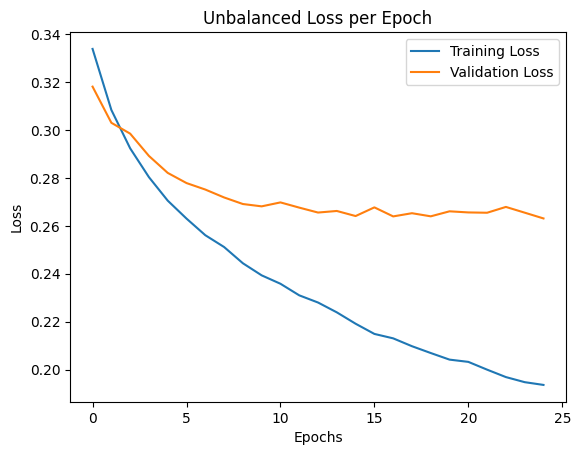

In [ ]:
# Graphing losses

plt.plot(tr_loss, label="Training Loss")
plt.plot(valid_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Unbalanced Loss per Epoch")
plt.legend()
plt.show()

The confusion matrix highlights that there are more negative values (residues that do not bond to the idp) than positive ones, which shows a bias towards them.

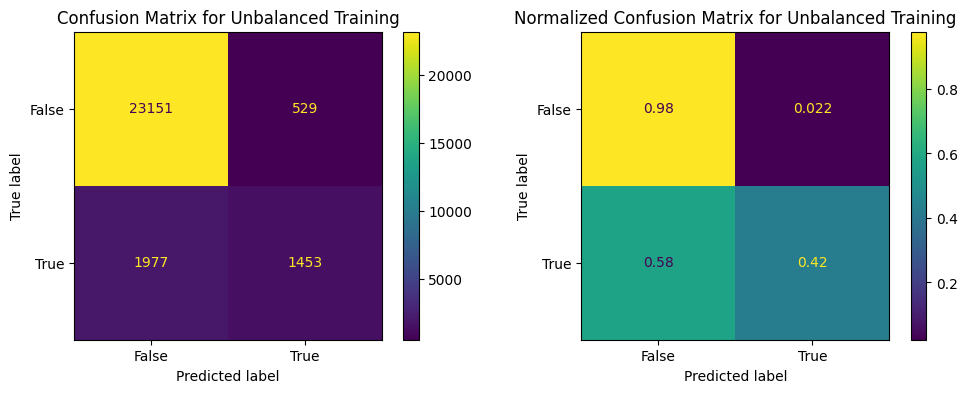

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm_mlp = confusion_matrix(y_test.cpu(), (torch.sigmoid(mlp(X_test.to(device))) > 0.5))
n_cm_mlp = cm_mlp.astype("float") / cm_mlp.sum(axis=1)[:, np.newaxis]
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm_mlp, display_labels = [False, True])
n_cm_display = ConfusionMatrixDisplay(confusion_matrix = n_cm_mlp, display_labels = [False, True])
axes[0].set_title("Confusion Matrix for Unbalanced Training")
axes[1].set_title("Normalized Confusion Matrix for Unbalanced Training")
axes[0] = cm_display.plot(ax=axes[0])
axes[1] = n_cm_display.plot(ax=axes[1])
plt.show()

The purpose of this next model is to train it off of an underfitted dataset where the amout of negative and positive residues are the same.

In [ ]:
pos_indices = (y == 1).nonzero(as_tuple=True)[0]
neg_indices = (y == 0).nonzero(as_tuple=True)[0]

# Randomly sample negatives to match the number of positives
torch.manual_seed(42)
sampled_neg_indices = neg_indices[torch.randperm(len(neg_indices))[:len(pos_indices)]]

# Combine and shuffle
balanced_indices = torch.cat([pos_indices, sampled_neg_indices])
balanced_indices = balanced_indices[torch.randperm(len(balanced_indices))]

# Build a balanced X and a balanced y
bal_X = X[balanced_indices]
bal_y = y[balanced_indices]

print(f"Balanced dataset: {len(bal_y)} total")
print(f"Positive: {(bal_y == 1).sum().item()}")
print(f"Negative: {(bal_y == 0).sum().item()}")

Balanced dataset: 34296 total
Positive: 17148
Negative: 17148


In [ ]:
indices = list(range(len(bal_X)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=bal_y)

bal_X_train, bal_X_test = bal_X[train_idx], bal_X[test_idx]
bal_y_train, bal_y_test = bal_y[train_idx], bal_y[test_idx]

In [ ]:
# Train an entirely new neural network with the underfitted data
b_mlp = ProteinMLP().to(device)

In [ ]:
b_optimizer = torch.optim.Adam(b_mlp.parameters(), lr=1e-3)

loss_fn = nn.BCEWithLogitsLoss()


b_train_ds = TensorDataset(bal_X_train, bal_y_train)
b_train_loader = DataLoader(b_train_ds, batch_size=32, shuffle=True)

b_val_ds = TensorDataset(bal_X_test, bal_y_test)
b_val_loader = DataLoader(b_val_ds, batch_size=32, shuffle=False)

bal_tr_loss = []
bal_valid_loss = []

# Training loss during each epoch
for epoch in range(25):
    b_mlp.train()
    bal_total_loss = 0
    for xb, yb in b_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = b_mlp(xb)
        loss = loss_fn(pred, yb)
        b_optimizer.zero_grad()
        loss.backward()
        b_optimizer.step()
        bal_total_loss += loss.item()

    b_mlp.eval()
    bal_val_loss = 0
    with torch.no_grad():
        for xb, yb in b_val_loader:
          xb, yb = xb.to(device), yb.to(device)
          pred = b_mlp(xb)
          loss = loss_fn(pred, yb)
          bal_val_loss += loss.item()

    #print(f"Epoch {epoch+1}: Training loss = {total_loss/len(train_loader):.4f}, Val loss = {val_loss/len(val_loader):.4f}")
    bal_valid_loss.append(bal_val_loss/len(b_val_loader))
    bal_tr_loss.append(bal_total_loss/len(b_train_loader))

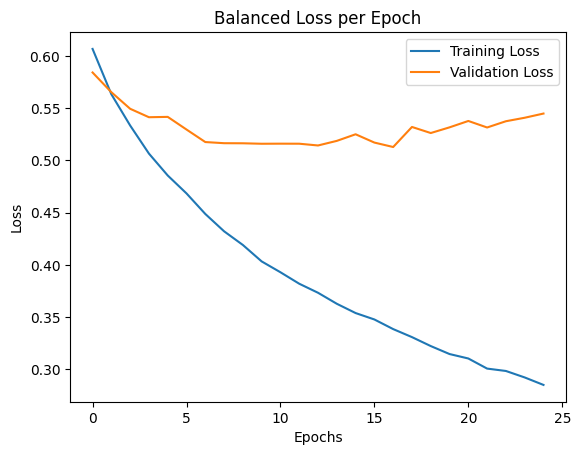

In [ ]:
plt.plot(bal_tr_loss, label="Training Loss")
plt.plot(bal_valid_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Balanced Loss per Epoch")
plt.show()

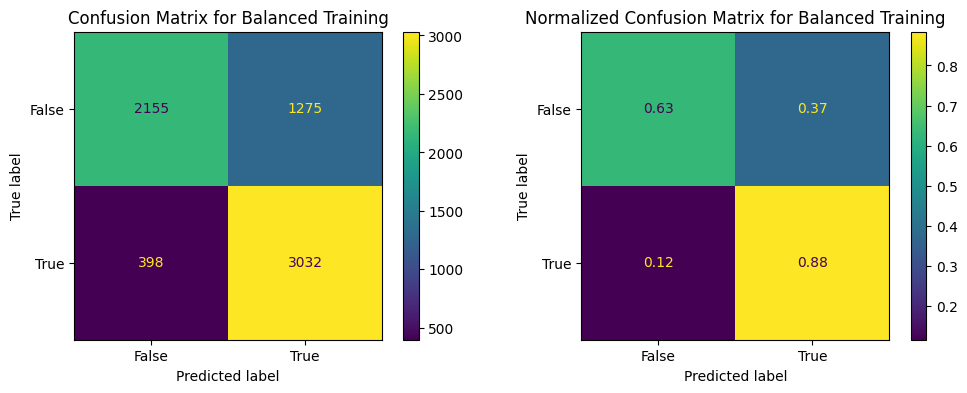

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
b_cm_mlp = confusion_matrix(bal_y_test.cpu(), (torch.sigmoid(b_mlp(bal_X_test.to(device))) > 0.3))
b_n_cm_mlp = b_cm_mlp.astype("float") / b_cm_mlp.sum(axis=1)[:, np.newaxis]
b_cm_display = ConfusionMatrixDisplay(confusion_matrix = b_cm_mlp, display_labels = [False, True])
b_n_cm_display = ConfusionMatrixDisplay(confusion_matrix = b_n_cm_mlp, display_labels = [False, True])
axes[0].set_title("Confusion Matrix for Balanced Training")
axes[1].set_title("Normalized Confusion Matrix for Balanced Training")
axes[0] = b_cm_display.plot(ax=axes[0])
axes[1] = b_n_cm_display.plot(ax=axes[1])
plt.show()

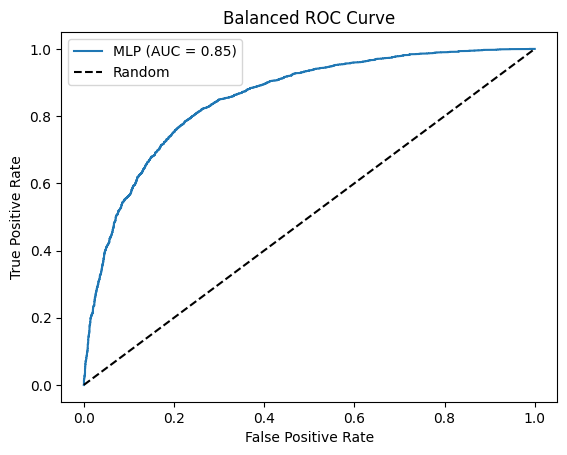

In [ ]:
b_mlp.eval()
with torch.no_grad():
    b_mlp_probs = torch.sigmoid(b_mlp(bal_X_test.to(device))).detach().cpu()

mlp_fpr, mlp_tpr, _ = roc_curve(bal_y_test.cpu(), b_mlp_probs)
mlp_auc = auc(mlp_fpr, mlp_tpr)

plt.plot(mlp_fpr, mlp_tpr, label=f"MLP (AUC = {mlp_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Balanced ROC Curve")
plt.legend()
plt.show()

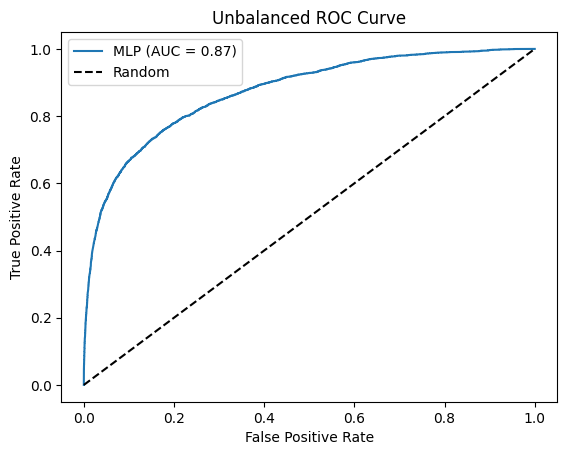

In [ ]:
mlp.eval()
with torch.no_grad():
    mlp_probs = torch.sigmoid(mlp(X_test.to(device))).detach().cpu()

mlp_fpr, mlp_tpr, _ = roc_curve(y_test.cpu(), mlp_probs)
mlp_auc = auc(mlp_fpr, mlp_tpr)

plt.plot(mlp_fpr, mlp_tpr, label=f"MLP (AUC = {mlp_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Unbalanced ROC Curve")
plt.legend()
plt.show()

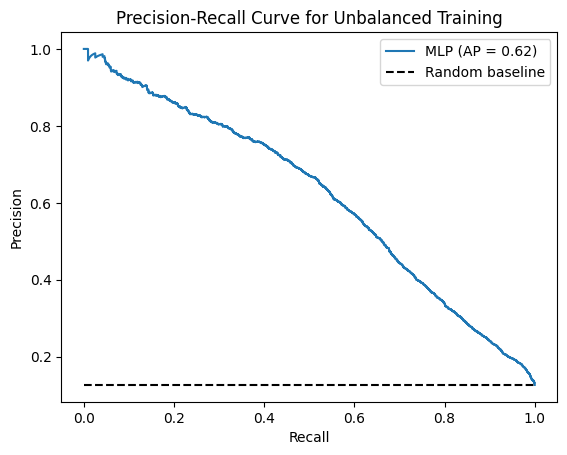

In [ ]:
# Precision and recall curve
mlp.eval()
with torch.no_grad():
  mlp_probs = torch.sigmoid(mlp(X_test.to(device))).detach().cpu()

mlp_precision, mlp_recall, _ = precision_recall_curve(y_test.cpu(), mlp_probs)
mlp_ap = average_precision_score(y_test.cpu(), mlp_probs)

plt.plot(mlp_recall, mlp_precision, label=f"MLP (AP = {mlp_ap:.2f})")

baseline = len(y_test[y_test == 1]) / (len(y_test[y_test == 1]) + len(y_test[y_test == 0]))
x1 = [0, 1]
y1 = [baseline, baseline]
plt.plot(x1, y1, "k--", label="Random baseline")  # baseline
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Unbalanced Training")
plt.legend()
plt.show()

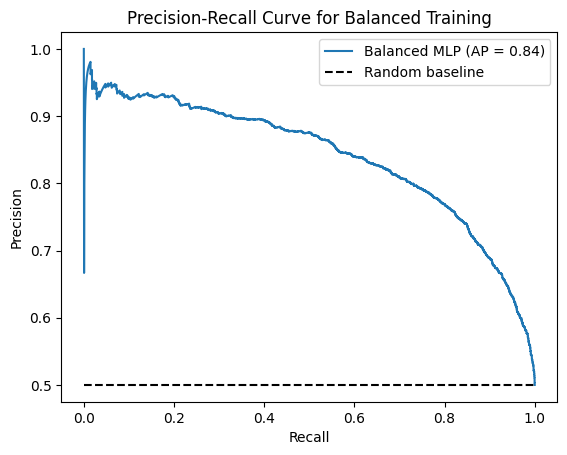

In [ ]:
# Precision and recall curve for balanced data
b_mlp.eval()
with torch.no_grad():
  b_mlp_probs = torch.sigmoid(b_mlp(bal_X_test.to(device))).detach().cpu()

b_mlp_precision, b_mlp_recall, _ = precision_recall_curve(bal_y_test.cpu(), b_mlp_probs)
b_mlp_ap = average_precision_score(bal_y_test.cpu(), b_mlp_probs)
bal_baseline = len(bal_y_test[bal_y_test == 1]) / (len(bal_y_test[bal_y_test == 1]) + len(bal_y_test[bal_y_test == 0]))
bal_y1 = [bal_baseline, bal_baseline]
plt.plot(b_mlp_recall, b_mlp_precision, label=f"Balanced MLP (AP = {b_mlp_ap:.2f})")
plt.plot(x1, bal_y1, "k--", label="Random baseline")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Balanced Training")
plt.legend()
plt.show()

# Binary Structures

In [ ]:
def get_true_binary_sequences(protein):
    binary_sequences = {}
    sequences = protein.get_sequences()
    chains = protein.get_chains()[0]

    if len(chains) < 2:
        print("Not enough chains to compare.")
        return

    # Build a set of (chain_id, resnum) pairs that interact that don't share values
    interacting = set(
        (interaction[4], interaction[5])
        for interaction in protein.get_interactions()
    )

    model = next(protein.structure.get_models())

    for chain_id in chains[1:]:
        binary_sequences[chain_id] = ""

        chain = model[chain_id]

        residues = [r for r in chain.get_residues() if r.id[0] == " "]

        for residue in residues:
            resnum = residue.id[1]
            if (chain_id, resnum) in interacting:
                binary_sequences[chain_id] += "1"
            else:
                binary_sequences[chain_id] += "0"

    return binary_sequences


In [ ]:
print(get_true_binary_sequences(protein_list[0]))

{'B': '0000000000000000000000000000000000001110000101100000000000000000000000000000000000000000001110011110100000000000000000000'}


In [ ]:
def get_predicted_binary_sequences(protein, neural_net, thres=0.5):
    binary_sequences = {}
    sequences = protein.get_sequences()
    chains = protein.get_chains()[0]
    embeddings = get_protein_embeddings(protein)
    model = next(protein.structure.get_models())
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    neural_net.to(device)
    neural_net.eval()

    if len(chains) < 2:
        print("Not enough chains to compare.")
        return

    for chain_id in chains[1:]:
        binary_sequences[chain_id] = ""
        chain_embed = embeddings[chain_id].squeeze(0)

        with torch.no_grad():
            logits = neural_net(chain_embed.to(device))
            probs = torch.sigmoid(logits)
            predicts = (probs > thres).cpu().int().cpu().tolist()

        binary_sequences[chain_id] = "".join(str(p) for p in predicts)
    return binary_sequences

In [ ]:
print(get_predicted_binary_sequences(protein_list[0], b_mlp))

{'B': '0011111000000100011000001001100000010110000101011011100000010000000000000101111011111100111110111111100100110100000000000'}


In [ ]:
print(get_predicted_binary_sequences(protein_list[0], mlp))

{'B': '0000000000000000000000000000000000000000000001000000000000000000000000000000000000000000001110001100100000000000000000000'}


In [ ]:
def get_protein_summary(protein):
  summary = f"Interactions: {protein.get_interactions()} \nSequences: {protein.get_sequences()} \nTrue Binary Sequences: {get_true_binary_sequences(protein)} \nUnbalanced Predicted Binary Sequences: {get_predicted_binary_sequences(protein, mlp)} \nBalanced Predicted Binary Sequences: {get_predicted_binary_sequences(protein, b_mlp)}"
  return summary


In [ ]:
print(get_protein_summary(protein_list[1]))

Interactions: [('MET', 'A', 44, 'LYS', 'B', 18), ('MET', 'A', 44, 'LYS', 'B', 19), ('LEU', 'A', 45, 'LYS', 'B', 18), ('LEU', 'A', 45, 'LYS', 'B', 19), ('LEU', 'A', 45, 'LYS', 'B', 62), ('PRO', 'A', 47, 'LYS', 'B', 18), ('PRO', 'A', 47, 'LYS', 'B', 19), ('PRO', 'A', 47, 'ASN', 'B', 76), ('ASP', 'A', 48, 'LYS', 'B', 19), ('ASP', 'A', 48, 'LYS', 'B', 62), ('ASP', 'A', 49, 'LYS', 'B', 19), ('ASP', 'A', 49, 'LYS', 'B', 60), ('ASP', 'A', 49, 'LYS', 'B', 62), ('ASP', 'A', 49, 'GLN', 'B', 64), ('ILE', 'A', 50, 'LYS', 'B', 19), ('ILE', 'A', 50, 'SER', 'B', 56), ('ILE', 'A', 50, 'LYS', 'B', 60), ('ILE', 'A', 50, 'LYS', 'B', 62), ('ILE', 'A', 50, 'GLN', 'B', 64), ('ILE', 'A', 50, 'GLN', 'B', 66), ('ILE', 'A', 50, 'ASN', 'B', 76), ('ILE', 'A', 50, 'HIS', 'B', 78), ('GLU', 'A', 51, 'LYS', 'B', 54), ('GLU', 'A', 51, 'SER', 'B', 56), ('GLU', 'A', 51, 'LYS', 'B', 60), ('GLU', 'A', 51, 'GLN', 'B', 66), ('GLU', 'A', 51, 'ASN', 'B', 76), ('GLN', 'A', 52, 'ILE', 'B', 55), ('GLN', 'A', 52, 'SER', 'B', 56),

In [ ]:
protein_sums = {}
for i in protein_list:
  try:
    protein_sums[i.get_pdb_id()] = get_protein_summary(i)
  except KeyError:
    continue

In [ ]:
for i in protein_sums:
  print(i)
  print(protein_sums[i])
  print()
# First half is the idp, second half is the other chain

1jsp
Interactions: [('HIS', 'A', 380, 'ILE', 'B', 1122), ('HIS', 'A', 380, 'PRO', 'B', 1123), ('LYS', 'A', 381, 'ILE', 'B', 1122), ('LYS', 'A', 381, 'PRO', 'B', 1123), ('LYS', 'A', 381, 'TYR', 'B', 1167), ('LYS', 'A', 381, 'ARG', 'B', 1169), ('LEU', 'A', 383, 'GLN', 'B', 1113), ('LEU', 'A', 383, 'PRO', 'B', 1114), ('LEU', 'A', 383, 'VAL', 'B', 1115), ('LEU', 'A', 383, 'LEU', 'B', 1120), ('LEU', 'A', 383, 'ILE', 'B', 1122), ('LEU', 'A', 383, 'ARG', 'B', 1173), ('LEU', 'A', 383, 'VAL', 'B', 1174), ('LEU', 'A', 383, 'PHE', 'B', 1177), ('MET', 'A', 384, 'TYR', 'B', 1167), ('MET', 'A', 384, 'ASN', 'B', 1168), ('MET', 'A', 384, 'ARG', 'B', 1169), ('MET', 'A', 384, 'SER', 'B', 1172), ('MET', 'A', 384, 'ARG', 'B', 1173), ('MET', 'A', 384, 'VAL', 'B', 1174), ('MET', 'A', 384, 'TYR', 'B', 1175), ('PHE', 'A', 385, 'ARG', 'B', 1173), ('PHE', 'A', 385, 'VAL', 'B', 1174), ('LYS', 'A', 386, 'LEU', 'B', 1120), ('LYS', 'A', 386, 'ARG', 'B', 1173)] 
Sequences: {'A': 'SHLKSKKGQSTSRHKLMFK', 'B': 'GSHMRKKI